# **RESULTS FILE**

In [ ]:
# submit job
bsub < task5_static_w8.sh

# list jobs
bjobs

# detailed job info
bjobs -l

# kill job
bkill <jobID>

# view output
cat task5_static_w8_<jobID>.out

# follow output live
tail -f task5_static_w8_<jobID>.out

# list output files
ls *.out

# copy results from HPC to local machine
scp username@hpc-address:/path/to/*.out .

# copy entire folder
scp -r username@hpc-address:/path/to/results_folder .

# make results folder (on HPC)
mkdir results

# save output explicitly inside job script
python run_subset_5.py 100 --workers 8 --time > results/static_w8.csv

# append instead of overwrite
>> results/static_w8.csv

___

### **``task2_reference_timing.sh``**

In [ ]:
#!/bin/bash
#BSUB -J t2_ref
#BSUB -q hpc
#BSUB -n 1
#BSUB -R "span[hosts=1]"
#BSUB -R "rusage[mem=4GB]"
#BSUB -W 00:30
#BSUB -oo task2_reference_timing_%J.out
#BSUB -eo task2_reference_timing_%J.err

python run_subset.py 20 --time

___

### **``task3_visualise.sh``**

In [ ]:
#!/bin/bash
#BSUB -J t3_vis
#BSUB -q hpc
#BSUB -n 1
#BSUB -R "span[hosts=1]"
#BSUB -R "rusage[mem=8GB]"
#BSUB -W 00:30
#BSUB -oo task3_visualize_%J.out
#BSUB -eo task3_visualize_%J.err

python visualise_results.py 3 --outdir figures_task3

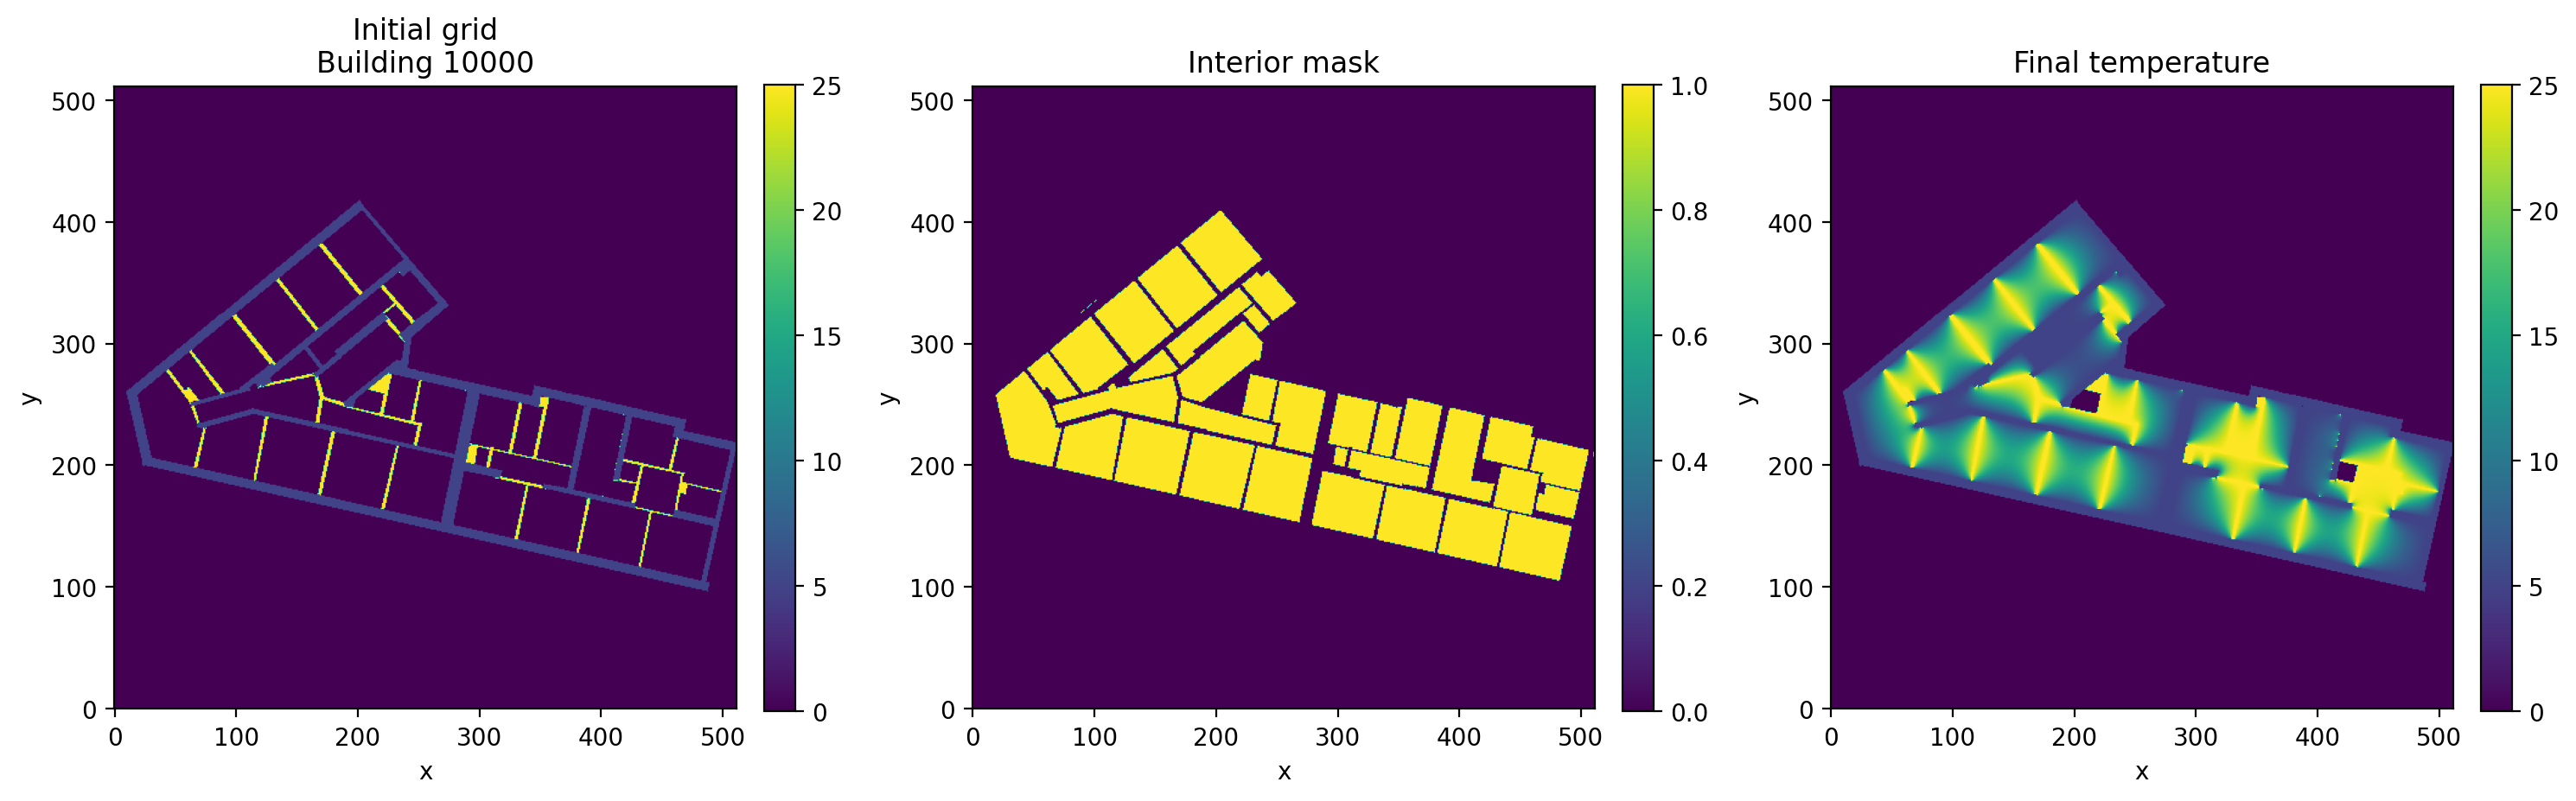

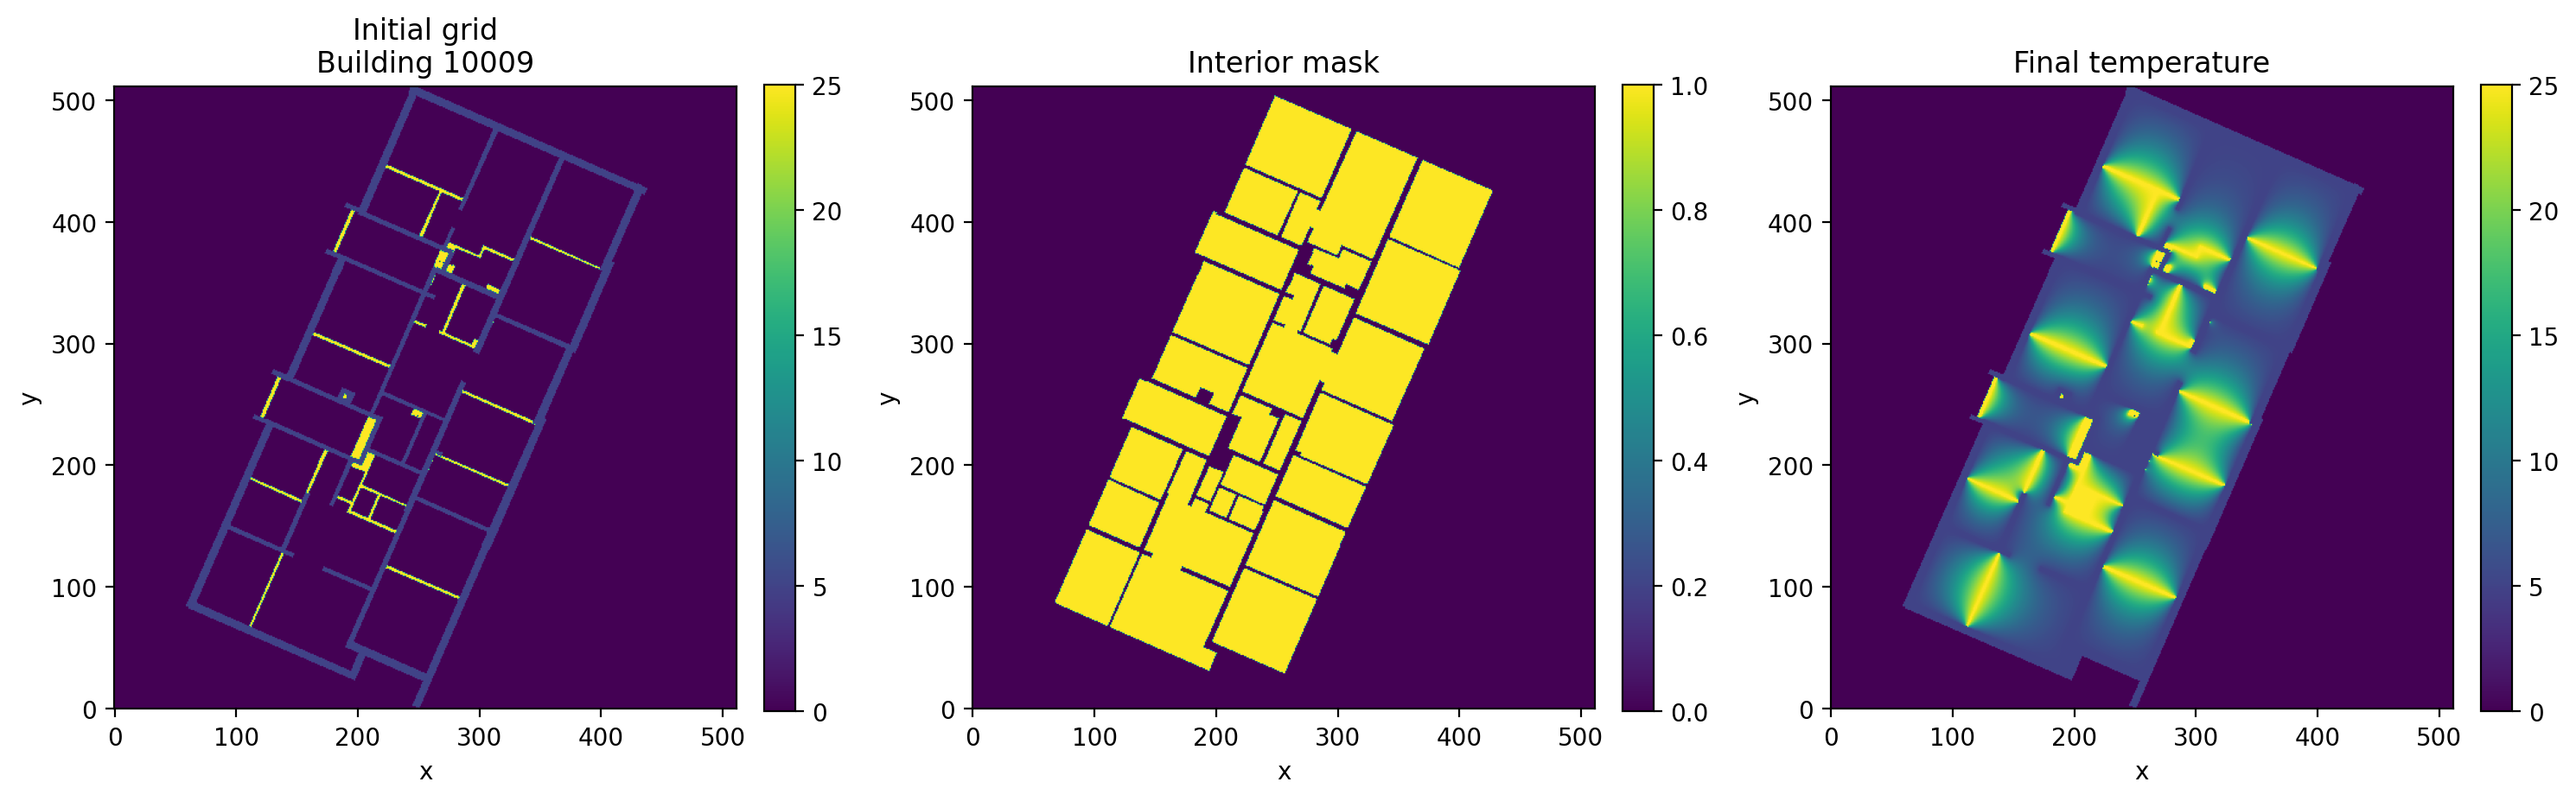

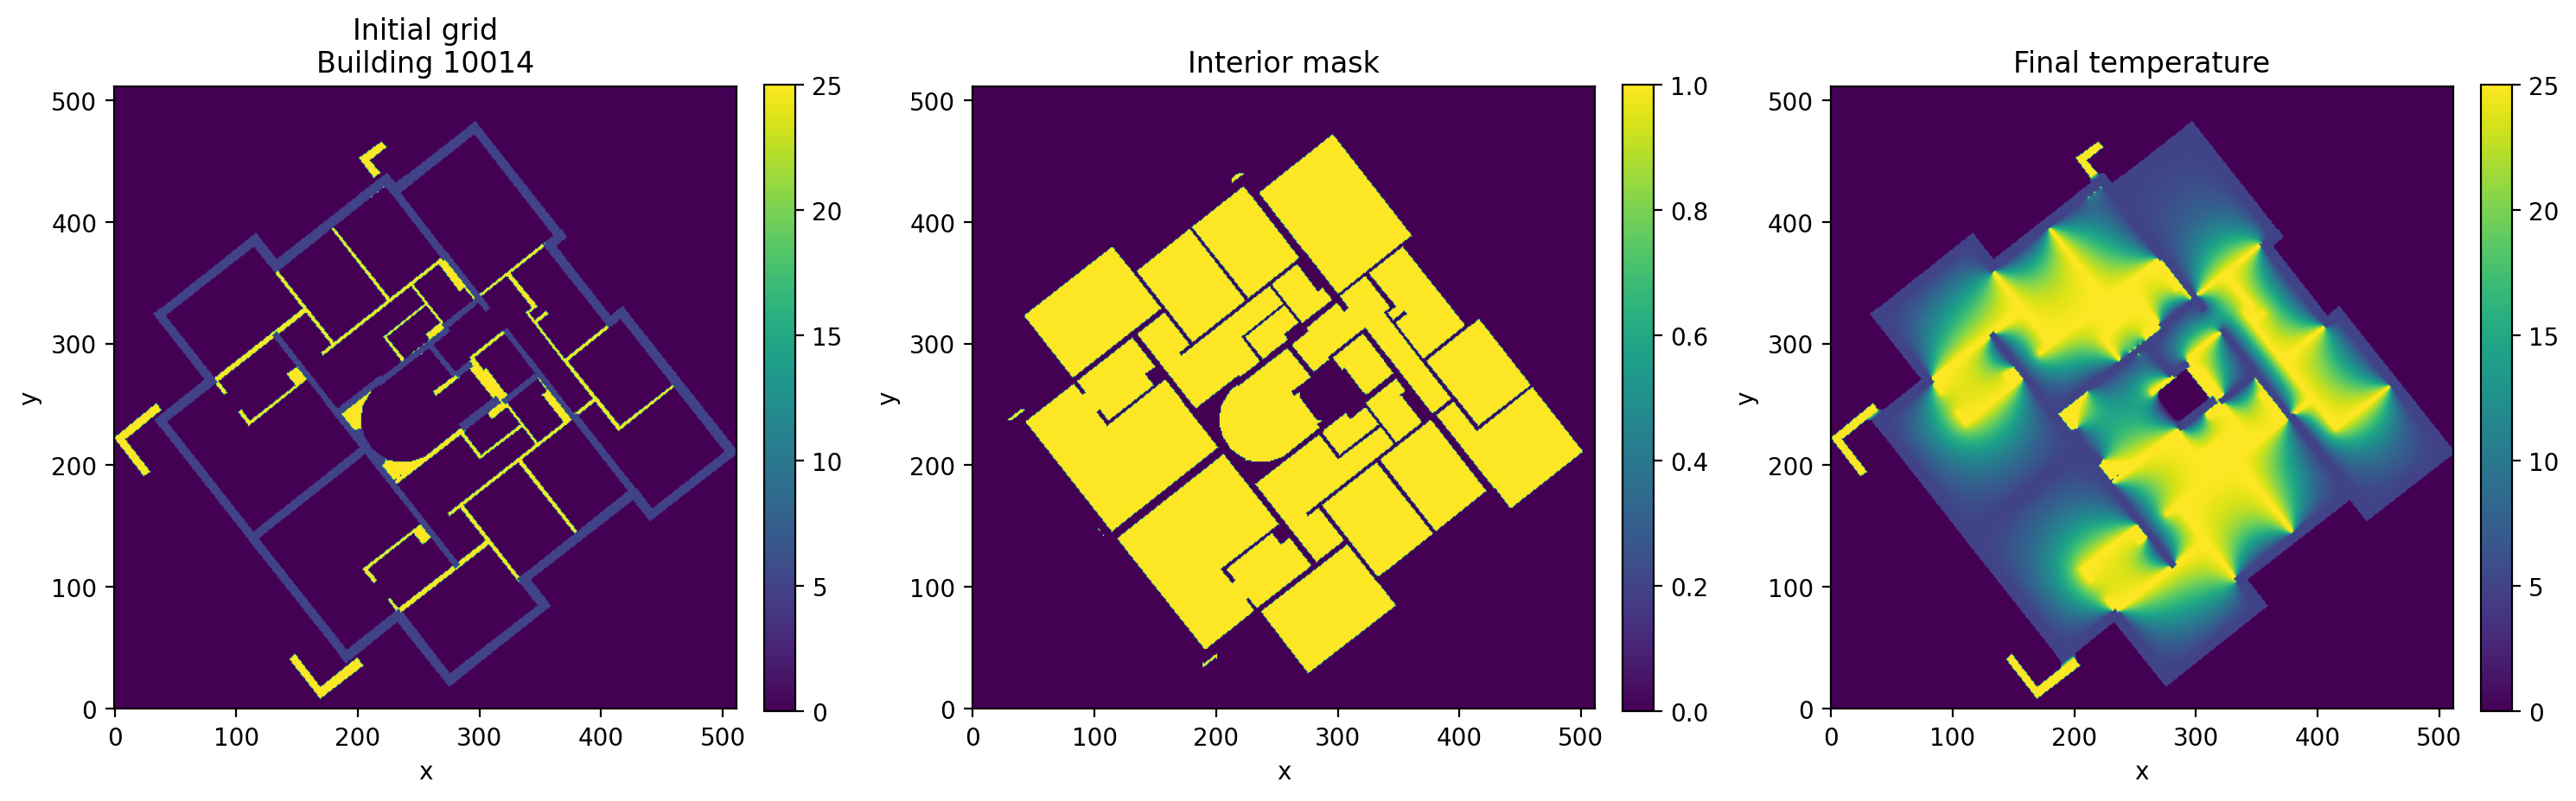

___

### **``task4_profile_reference.sh``**

In [ ]:
#!/bin/bash
#BSUB -J t4_prof
#BSUB -q hpc
#BSUB -n 1
#BSUB -R "span[hosts=1]"
#BSUB -R "rusage[mem=4GB]"
#BSUB -W 00:45
#BSUB -oo task4_profile_reference_%J.out
#BSUB -eo task4_profile_reference_%J.err

kernprof -l -v run_subset.py 1

___

### **``task5_static_wX.sh``**

In [ ]:
#!/bin/bash
#BSUB -J t5s_wX
#BSUB -q hpc
#BSUB -n X
#BSUB -R "span[hosts=1]"
#BSUB -R "rusage[mem=4GB]"
#BSUB -W 00:45
#BSUB -oo task5_static_wX_%J.out
#BSUB -eo task5_static_wX_%J.err

python run_subset_5.py 100 --workers X --time

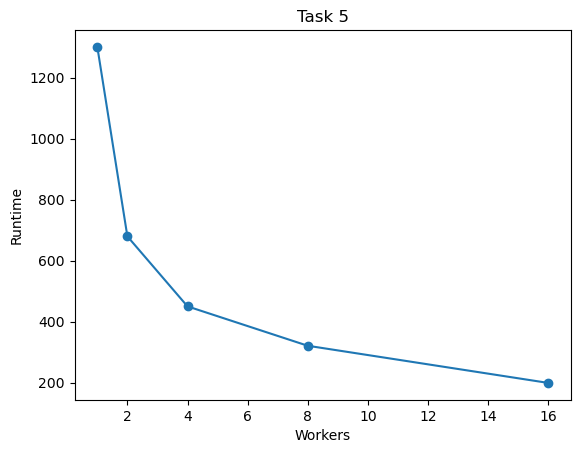

In [10]:
import matplotlib.pyplot as plt

# Given data (no extraction)
workers = [1, 2, 4, 8, 16]

task5 = [1300.789, 679.876, 450.448, 321.36, 199.563]
task6 = [1689.635, 675.171, 465.89, 245.574, 169.743]

# Plot Task 5
plt.figure()
plt.plot(workers, task5, marker='o')
plt.xlabel("Workers")
plt.ylabel("Runtime")
plt.title("Task 5")
plt.show()

___

### **``task6_dynamic_wX.sh``**

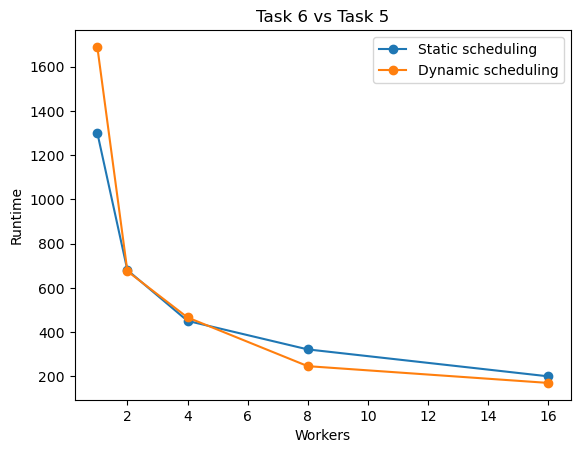

In [11]:
# Plot comparison
plt.figure()
plt.plot(workers, task5, marker='o', label="Static scheduling")
plt.plot(workers, task6, marker='o', label="Dynamic scheduling")
plt.xlabel("Workers")
plt.ylabel("Runtime")
plt.title("Task 6 vs Task 5")
plt.legend()
plt.show()

___

### **``task7_numba_static.sh``**

___

### **``task7_numba_dynamic.sh``**